In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("winequality-red.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 1599
Columns: 1


In [3]:
df.head()

,"fixed acidity;""volatile acidity"";""citric acid"";""residual sugar"";""chlorides"";""free sulfur dioxide"";""total sulfur dioxide"";""density"";""pH"";""sulphates"";""alcohol"";""quality"""
0,7.4;0.7;0;1.9;0.076;11;34;0.9978;3.51;0.56;9.4;5
1,7.8;0.88;0;2.6;0.098;25;67;0.9968;3.2;0.68;9.8;5
2,7.8;0.76;0.04;2.3;0.092;15;54;0.997;3.26;0.65;...
3,11.2;0.28;0.56;1.9;0.075;17;60;0.998;3.16;0.58...
4,7.4;0.7;0;1.9;0.076;11;34;0.9978;3.51;0.56;9.4;5


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 1 columns):
 #   Column                                                                                                                                                                   Non-Null Count  Dtype
---  ------                                                                                                                                                                   --------------  -----
 0   fixed acidity;"volatile acidity";"citric acid";"residual sugar";"chlorides";"free sulfur dioxide";"total sulfur dioxide";"density";"pH";"sulphates";"alcohol";"quality"  1599 non-null   str  
dtypes: str(1)
memory usage: 12.6 KB


In [5]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
fixed acidity;"volatile acidity";"citric acid";"residual sugar";"chlorides";"free sulfur dioxide";"total sulfur dioxide";"density";"pH";"sulphates";"alcohol";"quality"    0
dtype: int64


In [6]:
df.describe()

,"fixed acidity;""volatile acidity"";""citric acid"";""residual sugar"";""chlorides"";""free sulfur dioxide"";""total sulfur dioxide"";""density"";""pH"";""sulphates"";""alcohol"";""quality"""
count,1599
unique,1359
top,7.2;0.36;0.46;2.1;0.074;24;44;0.99534;3.4;0.85...
freq,4


In [7]:
quality_counts = df['quality'].value_counts().sort_index()

print("Wine Quality Distribution:")
print(quality_counts)

KeyError: 'quality'

In [8]:
print(df.columns.tolist())

['fixed acidity;"volatile acidity";"citric acid";"residual sugar";"chlorides";"free sulfur dioxide";"total sulfur dioxide";"density";"pH";"sulphates";"alcohol";"quality"']


In [9]:
df = pd.read_csv("winequality-red.csv")

In [10]:
df = pd.read_csv("winequality-red.csv", sep=';')

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 1599
Columns: 12


In [11]:
print(df.columns.tolist())

['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


In [12]:
quality_counts = df['quality'].value_counts().sort_index()

print("Wine Quality Distribution:")
print(quality_counts)

Wine Quality Distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


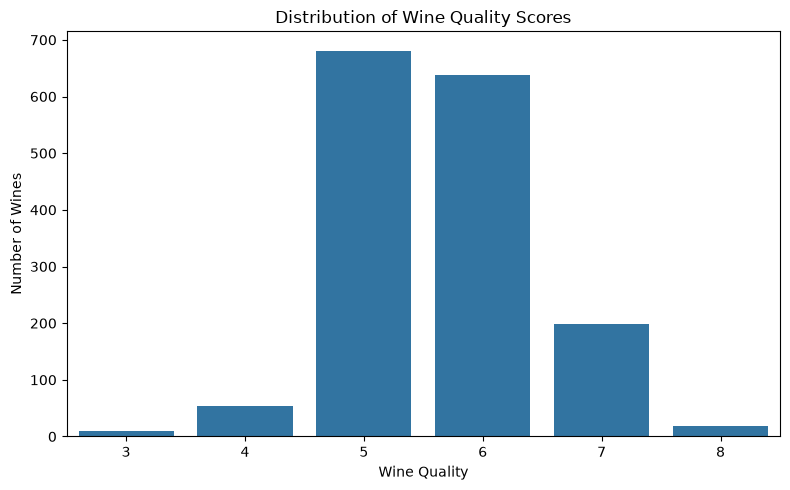

In [13]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='quality')

plt.title('Distribution of Wine Quality Scores')
plt.xlabel('Wine Quality')
plt.ylabel('Number of Wines')

plt.tight_layout()
plt.savefig("images/quality_distribution.png", bbox_inches="tight")

plt.show()

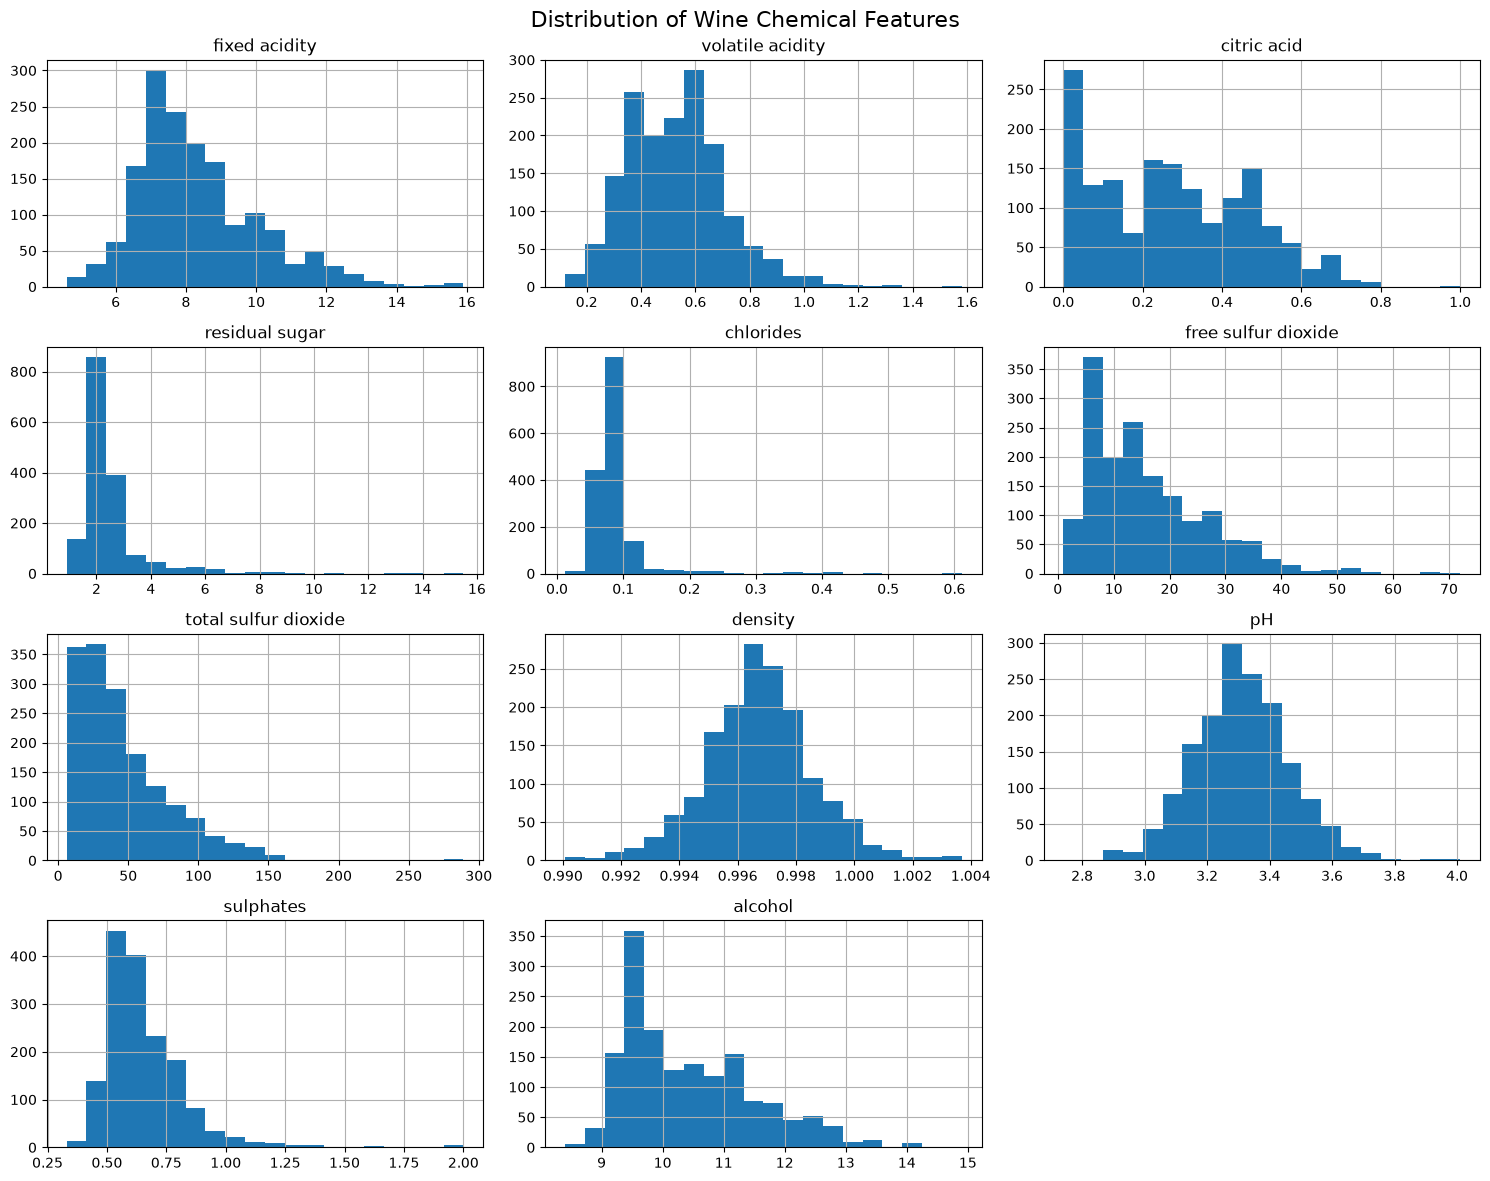

In [14]:
features = df.drop('quality', axis=1)

features.hist(
    figsize=(15, 12),
    bins=20
)

plt.suptitle(
    'Distribution of Wine Chemical Features',
    fontsize=16
)

plt.tight_layout()
plt.savefig(
    "images/chemical_features_distribution.png",
    bbox_inches="tight"
)

plt.show()

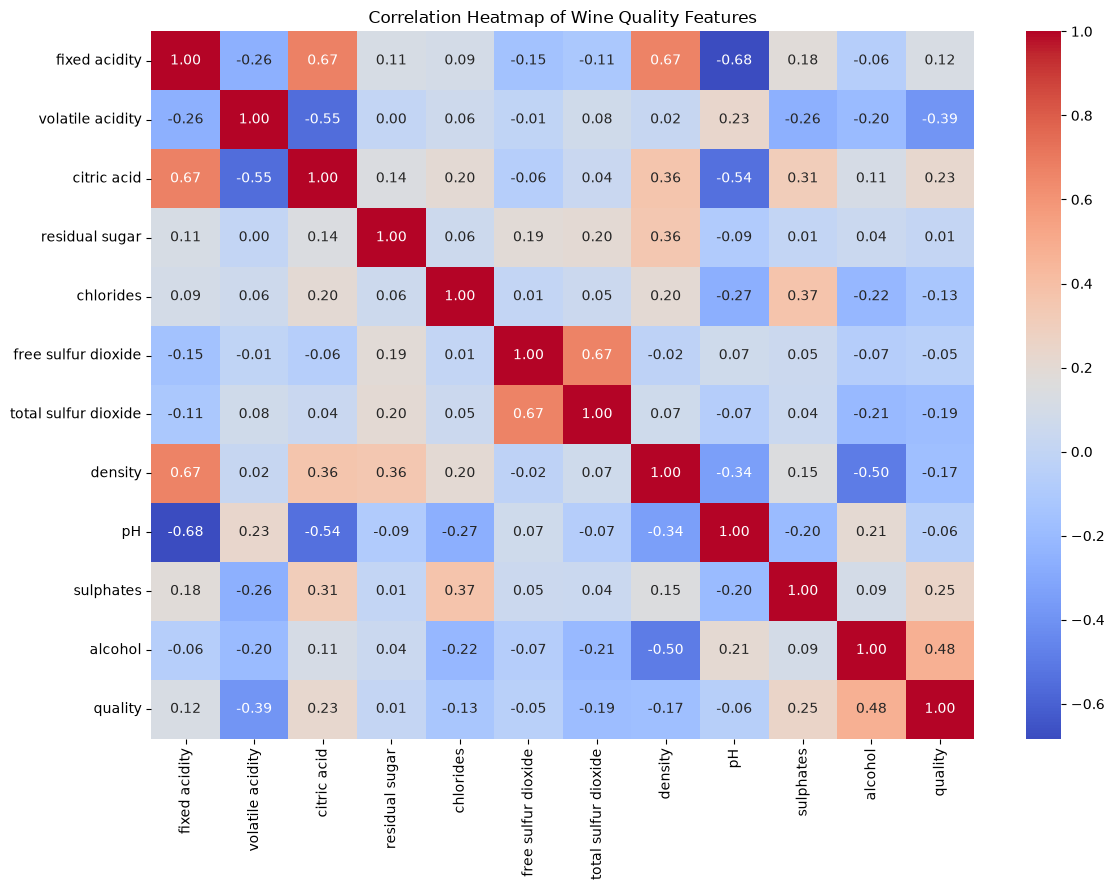

In [15]:
plt.figure(figsize=(12, 9))

correlation = df.corr()

sns.heatmap(
    correlation,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Heatmap of Wine Quality Features')

plt.tight_layout()
plt.savefig(
    "images/correlation_heatmap.png",
    bbox_inches="tight"
)

plt.show()

In [16]:
quality_counts = df['quality'].value_counts().sort_index()

print("Wine Quality Class Distribution:")
print(quality_counts)

Wine Quality Class Distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


In [17]:
quality_percentages = (
    df['quality']
    .value_counts(normalize=True)
    .sort_index() * 100
)

print("Wine Quality Class Percentage:")
print(quality_percentages.round(2))

Wine Quality Class Percentage:
quality
3     0.63
4     3.31
5    42.59
6    39.90
7    12.45
8     1.13
Name: proportion, dtype: float64


## Class Imbalance Discussion

The wine quality scores are not evenly distributed across the dataset. Most wine samples belong to the middle quality scores, particularly quality 5 and 6, while very few samples belong to the extreme scores such as 3 and 8.

This class imbalance can affect classification models because models may learn the majority classes more effectively while performing poorly on underrepresented classes. Accuracy alone may therefore not provide a complete picture of model performance.

To reduce the impact of the uneven original quality distribution, the quality scores will be grouped into three broader categories: Low, Medium, and High.


In [18]:
def classify_quality(score):
    if score <= 4:
        return 'Low'
    elif score <= 6:
        return 'Medium'
    else:
        return 'High'

df['quality_class'] = df['quality'].apply(classify_quality)

print(df[['quality', 'quality_class']].head(10))

   quality quality_class
0        5        Medium
1        5        Medium
2        5        Medium
3        6        Medium
4        5        Medium
5        5        Medium
6        5        Medium
7        7          High
8        7          High
9        5        Medium


In [19]:
print("New Quality Class Distribution:")
print(df['quality_class'].value_counts())

New Quality Class Distribution:
quality_class
Medium    1319
High       217
Low         63
Name: count, dtype: int64


## Feature Engineering

The original wine quality score ranges from 3 to 8 and is treated as an ordinal classification target. However, the individual quality scores are highly imbalanced, with most observations concentrated around scores 5 and 6.

For this project, the target variable was grouped into three meaningful categories:

* **Low:** Quality scores 3–4
* **Medium:** Quality scores 5–6
* **High:** Quality scores 7–8

This 3-class approach reduces the impact of rare individual quality scores while preserving the overall meaning of wine quality. It also makes the classification task more practical for comparing different machine learning models.

The original `quality` column is retained for reference, while `quality_class` is used as the classification target.


In [20]:
X = df.drop(['quality', 'quality_class'], axis=1)

y = df['quality_class']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1599, 11)
Target shape: (1599,)


In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1279, 11)
Testing data: (320, 11)


In [22]:
stratify=y

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


In [24]:
print("Training class distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting class distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training class distribution:
quality_class
Medium    0.825
High      0.136
Low       0.039
Name: proportion, dtype: float64

Testing class distribution:
quality_class
Medium    0.825
High      0.134
Low       0.041
Name: proportion, dtype: float64


In [25]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [26]:
rf_pred = rf_model.predict(X_test)

print("Random Forest predictions generated successfully!")
print("First 10 predictions:")
print(rf_pred[:10])

Random Forest predictions generated successfully!
First 10 predictions:
['Medium' 'Medium' 'Medium' 'High' 'Medium' 'Medium' 'Medium' 'High'
 'Medium' 'Medium']


In [27]:
from sklearn.metrics import accuracy_score, classification_report

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 0.859375

Classification Report:
              precision    recall  f1-score   support

        High       0.67      0.51      0.58        43
         Low       0.00      0.00      0.00        13
      Medium       0.88      0.96      0.92       264

    accuracy                           0.86       320
   macro avg       0.52      0.49      0.50       320
weighted avg       0.82      0.86      0.84       320



C:\Users\sravy\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sravy\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sravy\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

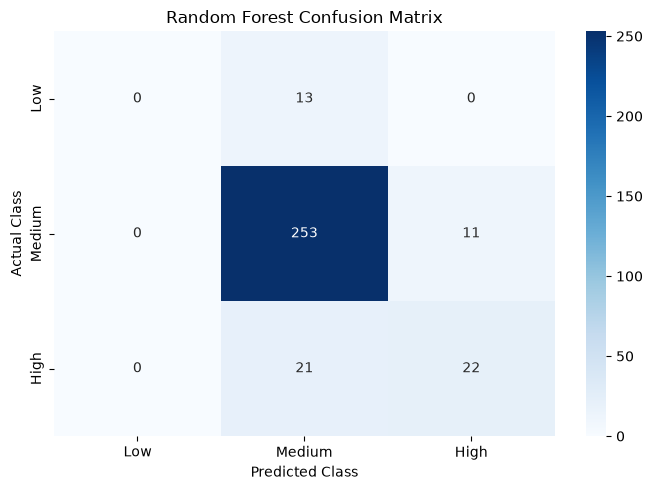

In [28]:
from sklearn.metrics import confusion_matrix

rf_cm = confusion_matrix(
    y_test,
    rf_pred,
    labels=['Low', 'Medium', 'High']
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Low', 'Medium', 'High'],
    yticklabels=['Low', 'Medium', 'High']
)

plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

plt.tight_layout()
plt.savefig(
    "images/random_forest_confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

In [29]:
from sklearn.linear_model import SGDClassifier

sgd_model = SGDClassifier(
    random_state=42,
    max_iter=1000,
    tol=1e-3
)

sgd_model.fit(X_train_scaled, y_train)

print("SGD Classifier trained successfully!")

SGD Classifier trained successfully!


In [30]:
sgd_pred = sgd_model.predict(X_test_scaled)

print("SGD predictions generated successfully!")
print("First 10 predictions:")
print(sgd_pred[:10])

SGD predictions generated successfully!
First 10 predictions:
['Medium' 'Medium' 'Medium' 'High' 'Medium' 'Medium' 'Medium' 'Medium'
 'Medium' 'Medium']


In [31]:
sgd_accuracy = accuracy_score(y_test, sgd_pred)

print("SGD Classifier Accuracy:", sgd_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, sgd_pred))

SGD Classifier Accuracy: 0.825

Classification Report:
              precision    recall  f1-score   support

        High       0.52      0.33      0.40        43
         Low       0.00      0.00      0.00        13
      Medium       0.86      0.95      0.90       264

    accuracy                           0.82       320
   macro avg       0.46      0.42      0.43       320
weighted avg       0.78      0.82      0.80       320



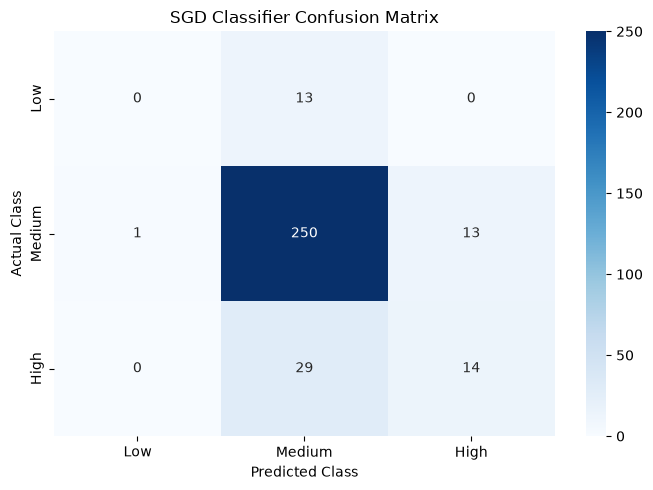

In [32]:
sgd_cm = confusion_matrix(
    y_test,
    sgd_pred,
    labels=['Low', 'Medium', 'High']
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    sgd_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Low', 'Medium', 'High'],
    yticklabels=['Low', 'Medium', 'High']
)

plt.title('SGD Classifier Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

plt.tight_layout()
plt.savefig(
    "images/sgd_confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

In [33]:
from sklearn.svm import SVC

svc_model = SVC(
    kernel='rbf',
    random_state=42
)

svc_model.fit(X_train_scaled, y_train)

print("SVC model trained successfully!")

SVC model trained successfully!


In [34]:
svc_pred = svc_model.predict(X_test_scaled)

print("SVC predictions generated successfully!")
print("First 10 predictions:")
print(svc_pred[:10])

SVC predictions generated successfully!
First 10 predictions:
['Medium' 'Medium' 'Medium' 'High' 'Medium' 'Medium' 'Medium' 'High'
 'Medium' 'Medium']


In [35]:
svc_accuracy = accuracy_score(y_test, svc_pred)

print("SVC Accuracy:", svc_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, svc_pred))

SVC Accuracy: 0.84375

Classification Report:
              precision    recall  f1-score   support

        High       0.64      0.33      0.43        43
         Low       0.00      0.00      0.00        13
      Medium       0.86      0.97      0.91       264

    accuracy                           0.84       320
   macro avg       0.50      0.43      0.45       320
weighted avg       0.79      0.84      0.81       320



C:\Users\sravy\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sravy\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sravy\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

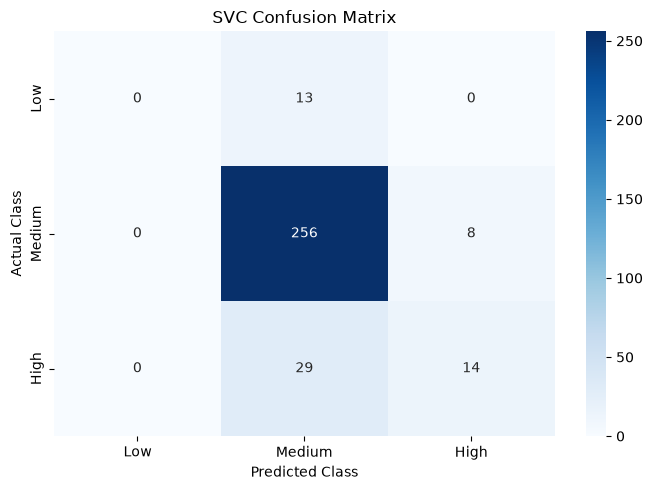

In [36]:
svc_cm = confusion_matrix(
    y_test,
    svc_pred,
    labels=['Low', 'Medium', 'High']
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    svc_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Low', 'Medium', 'High'],
    yticklabels=['Low', 'Medium', 'High']
)

plt.title('SVC Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

plt.tight_layout()
plt.savefig(
    "images/svc_confusion_matrix.png",
    bbox_inches="tight"
)

plt.show()

In [37]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    'Importance',
    ascending=False
)

print("Random Forest Feature Importance:")
display(feature_importance)

Random Forest Feature Importance:


,Feature,Importance
10,alcohol,0.147945
1,volatile acidity,0.128305
9,sulphates,0.105831
7,density,0.091750
2,citric acid,0.088894
0,fixed acidity,0.081780
6,total sulfur dioxide,0.080273
4,chlorides,0.072976
3,residual sugar,0.071831
8,pH,0.068416


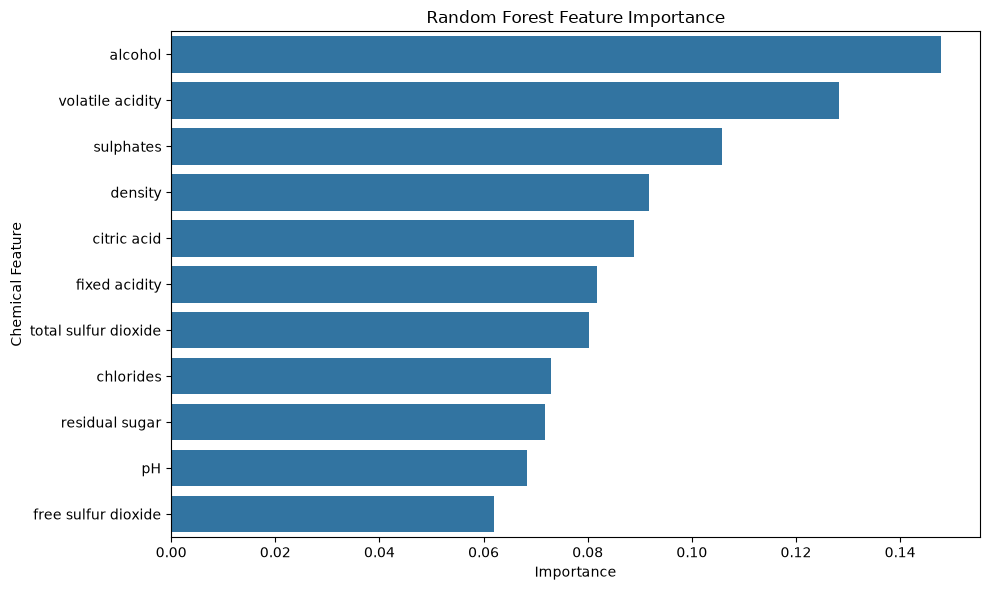

In [38]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Chemical Feature')

plt.tight_layout()

plt.savefig(
    "images/random_forest_feature_importance.png",
    bbox_inches="tight"
)

plt.show()

In [39]:
from sklearn.metrics import precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    'Model': [
        'Random Forest',
        'SGD Classifier',
        'SVC'
    ],
    'Accuracy': [
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, sgd_pred),
        accuracy_score(y_test, svc_pred)
    ],
    'Precision': [
        precision_score(y_test, rf_pred, average='weighted', zero_division=0),
        precision_score(y_test, sgd_pred, average='weighted', zero_division=0),
        precision_score(y_test, svc_pred, average='weighted', zero_division=0)
    ],
    'Recall': [
        recall_score(y_test, rf_pred, average='weighted', zero_division=0),
        recall_score(y_test, sgd_pred, average='weighted', zero_division=0),
        recall_score(y_test, svc_pred, average='weighted', zero_division=0)
    ],
    'F1 Score': [
        f1_score(y_test, rf_pred, average='weighted', zero_division=0),
        f1_score(y_test, sgd_pred, average='weighted', zero_division=0),
        f1_score(y_test, svc_pred, average='weighted', zero_division=0)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.859375,0.816848,0.859375,0.835419
1,SGD Classifier,0.825000,0.776012,0.825000,0.795656
2,SVC,0.843750,0.794236,0.843750,0.809486


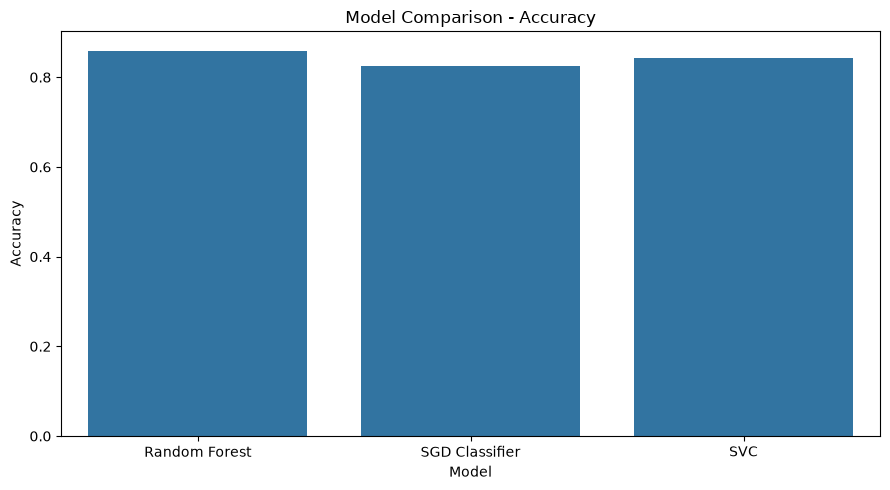

In [40]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=comparison,
    x='Model',
    y='Accuracy'
)

plt.title('Model Comparison - Accuracy')
plt.xlabel('Model')
plt.ylabel('Accuracy')

plt.tight_layout()

plt.savefig(
    "images/model_comparison.png",
    bbox_inches="tight"
)

plt.show()

## Conclusion

In this project, three machine learning classification models — Random Forest, SGD Classifier, and SVC — were trained to predict wine quality categories based on physicochemical properties.

The original wine quality scores were grouped into three classes: **Low (3–4), Medium (5–6), and High (7–8)**. This feature engineering step reduced the effect of the highly imbalanced individual quality scores while preserving meaningful quality categories.

A **stratified 80:20 train-test split** was used to maintain similar class proportions in both training and testing datasets. StandardScaler was applied to the features used by SGD and SVC.

Among the three models, **Random Forest performed the best**, achieving an accuracy of **85.94%** and a weighted F1 score of **0.8354**. SVC achieved **84.38% accuracy**, while SGD Classifier achieved **82.50% accuracy**.

Based on the test results, **Random Forest is the most suitable model for deployment among the three tested models** because it achieved the highest accuracy, precision, recall, and F1 score. The Random Forest feature importance analysis also provides useful insight into which chemical properties contribute most to wine quality classification.

Overall, the results demonstrate that physicochemical properties can be used effectively to classify wines into broader quality categories. For future improvement, class-weighting, hyperparameter tuning, cross-validation, and additional evaluation metrics such as macro F1-score could be explored to improve performance on the underrepresented quality classes.
